# Major Data Analytics Project

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn





**Submitted by:** Aparna Singh

**AICTE Student ID:** STU6a51f0af6b3da1783754927

**College:** JSS Academy of Technical Education, Noida


## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
# Load the dataset

from google.colab import files
files.upload()

file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
Dataset loaded successfully.


## 4. Initial Data Understanding

In [6]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
# Top 5 rows

df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [9]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [10]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [13]:
# Categorical summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**Note:** The dataset has 4,000 rows and 28 columns. The categorical summary shows 8 states, 10 districts, 8 crops, 3 seasons and 4 irrigation methods, with Kharif (1,779 records) the most frequent season and Flood (1,310 records) the most frequent irrigation method. This gives a first sense of scale and category balance before moving on to a formal data quality check.

## 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

**Student task:** Explain what you observe and justify each cleaning decision.

In [14]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


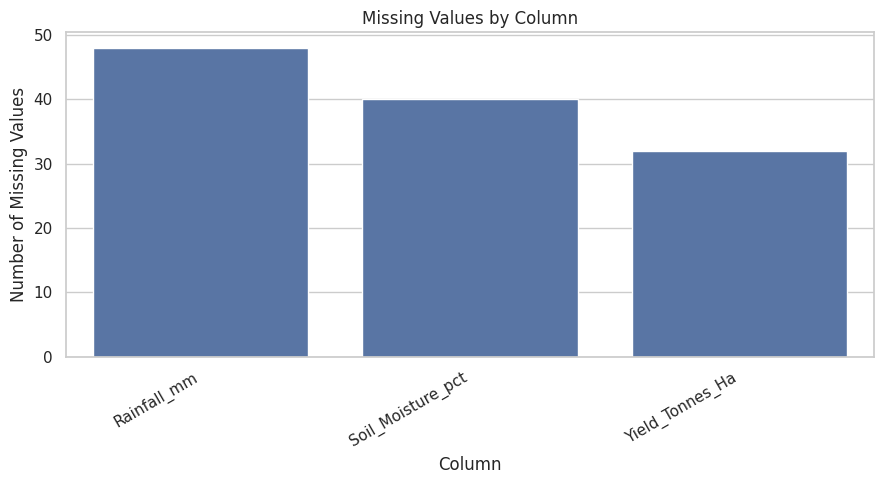

In [15]:
# Visualize missing values

plt.figure(figsize=(9, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

**Observation:** Three columns carry missing values — `Rainfall_mm` (48, 1.2%), `Soil_Moisture_pct` (40, 1.0%) and `Yield_Tonnes_Ha` (32, 0.8%) — together under 0.5% of all cells in the dataset. These are exactly the fields the seasonal comparison depends on, so they are treated carefully in Section 6 rather than dropped outright.

In [16]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
print("Number of duplicate Farm_IDs:", df.duplicated(subset=["Farm_ID"]).sum())

Number of duplicate rows: 0
Number of duplicate Farm_IDs: 0


In [17]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


**Observation:** No duplicate rows or duplicate Farm IDs were found, so the shape is unchanged at (4000, 28). This step is still run explicitly, since assuming a dataset has no duplicates without checking is a common source of silent errors.

In [18]:
# Check data types again

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [19]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


**Observation:** `Farm_ID` is a unique identifier (4,000 unique values, one per row) and is not used as an analytical variable. `State` (8), `District` (10), `Crop` (8), `Season` (3) and `Irrigation_Method` (4) are all clean, consistently-spelled categories with no stray values, typos or inconsistent casing — so no text-cleaning/standardization is required for these columns.

In [20]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


## 6. Data Cleaning and Treatment

This section acts on the observations from Section 5: missing values are imputed with a justified strategy, and the one column that looked suspicious in the numerical summary (`Yield_Tonnes_Ha`) is investigated before deciding whether it needs correction.

**Cleaning decision — missing values:** Rather than filling gaps with a single overall column mean (or dropping the ~120 affected rows), each missing value is filled with the **median of its own season**. Rainfall alone averages ~852mm in Kharif but only ~299mm in Zaid; filling both seasons' gaps with one global mean would quietly bias the Zaid rows upward and the Kharif rows downward, undermining the very seasonal comparison this project is built around. Median (rather than mean) is used to reduce sensitivity to the extreme values already flagged in `Yield_Tonnes_Ha`.

In [21]:
# Handle missing values using season-wise median

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after cleaning:", df.isnull().sum().sum())

Remaining missing values after cleaning: 0


**Outlier check — Yield_Tonnes_Ha:** the numerical summary in Section 4 showed a 75th percentile of only 2.84 t/ha against a maximum of 101.44 t/ha, which is worth investigating before deciding whether to treat it as an error.

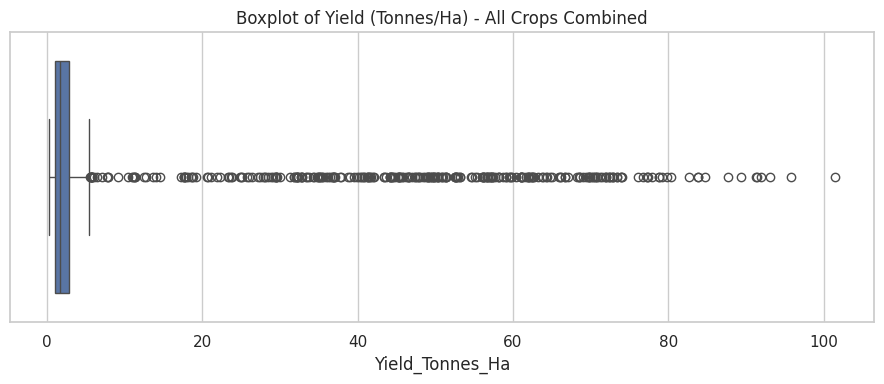

In [22]:
# Boxplot to check for outliers in Yield_Tonnes_Ha

plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Yield_Tonnes_Ha"])
plt.title("Boxplot of Yield (Tonnes/Ha) - All Crops Combined")
plt.tight_layout()
plt.show()

In [23]:
# IQR-based outlier check

Q1, Q3 = df["Yield_Tonnes_Ha"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("IQR upper bound:", round(upper_bound, 2))
print("Rows above upper bound:", (df["Yield_Tonnes_Ha"] > upper_bound).sum())
print(df.loc[df["Yield_Tonnes_Ha"] > upper_bound, "Crop"].value_counts())

IQR upper bound: 5.5
Rows above upper bound: 302
Crop
Sugarcane    293
Maize          7
Rice           2
Name: count, dtype: int64


**Cleaning decision — outliers:** every single flagged row belongs to **Sugarcane**. This is not a data error — sugarcane is harvested as whole cane stalks and genuinely yields 40-100+ tonnes/hectare in real farming, compared to 1-6 t/ha for grain and pulse crops. These rows are **kept, not removed**; instead, `Crop` is used as a grouping variable so yield is compared within each crop rather than pooled across all eight crops, wherever that comparison matters (Sections 8, 9 and 11).

## 7. Feature / Variable Review

Before running statistics, it helps to explicitly separate the dataset's columns into numerical and categorical variables, since each type needs different treatment in the analysis ahead.

In [24]:
# Classify columns into numerical and categorical variables

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical variables ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical variables ({len(categorical_cols)}):")
print(categorical_cols)

Numerical variables (22):
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical variables (6):
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [25]:
# Quick review table: role of each variable in the analysis

variable_review = pd.DataFrame({
    "Column": ["Farm_ID", "State", "District", "Crop", "Season", "Irrigation_Method",
               "Farm_Area_Hectares", "Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct",
               "Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score",
               "Yield_Tonnes_Ha, Production_Tonnes",
               "Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR",
               "Water_Used_m3, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct"],
    "Type": ["Identifier (excluded from analysis)", "Categorical", "Categorical", "Categorical",
             "Categorical (primary comparison variable)", "Categorical",
             "Numerical (size)", "Numerical (environmental)", "Numerical (farming inputs)",
             "Numerical (production outcome)", "Numerical (economic outcome)", "Numerical (resource/risk outcome)"]
})
variable_review

,Column,Type
0,Farm_ID,Identifier (excluded from analysis)
1,State,Categorical
2,District,Categorical
3,Crop,Categorical
4,Season,Categorical (primary comparison variable)
5,Irrigation_Method,Categorical
6,Farm_Area_Hectares,Numerical (size)
7,"Rainfall_mm, Avg_Temperature_C, Humidity_pct, ...",Numerical (environmental)
8,"Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg...",Numerical (farming inputs)
9,"Yield_Tonnes_Ha, Production_Tonnes",Numerical (production outcome)


**Note:** `Season` is the categorical variable this entire project is organized around — every subsequent univariate, bivariate and multivariate section treats it as the primary grouping variable. `Farm_ID` is a unique row identifier and is excluded from all statistical and visual analysis.

## 8. Descriptive Statistics

A season-wise summary of the key environmental, production and economic variables, as a first look before the deeper univariate/bivariate/multivariate analysis.

In [26]:
# Season-wise descriptive statistics for key metrics

season_order = ["Kharif", "Rabi", "Zaid"]
key_metrics = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Yield_Tonnes_Ha",
               "Total_Cost_INR", "Revenue_INR", "Profit_INR", "Water_Efficiency_t_per_1000m3"]

df.groupby("Season")[key_metrics].mean().reindex(season_order)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,,,,
Kharif,852.11,28.45,71.81,5.63,"531,804.41","710,719.06","178,914.65",5.89
Rabi,435.94,23.49,57.89,5.04,"513,836.58","601,526.05","87,689.47",5.19
Zaid,299.12,31.04,52.01,4.64,"543,976.73","519,171.90","-24,804.82",4.41


**Note:** Even a simple season-wise mean comparison hints at a pattern — rainfall, humidity and profit all fall from Kharif to Zaid. The rest of the notebook investigates whether this pattern is statistically meaningful and what is driving it.

In [27]:
# Median and standard deviation by season (in addition to the mean above)

df.groupby("Season")[key_metrics].agg(["median", "std"]).reindex(season_order)

Rainfall_mm        Avg_Temperature_C      Humidity_pct       \
            median    std            median  std       median  std   
Season                                                               
Kharif      854.75 181.57             28.50 2.51        71.90 8.86   
Rabi        430.30 174.69             23.50 2.46        58.10 9.00   
Zaid        283.30 152.56             31.00 2.55        52.35 9.05   

       Yield_Tonnes_Ha       Total_Cost_INR            Revenue_INR             \
                median   std         median        std      median        std   
Season                                                                          
Kharif            1.95 14.39     524,840.00 298,487.69  520,196.00 708,710.37   
Rabi              1.66 12.75     506,733.00 288,386.89  438,156.00 584,545.52   
Zaid              1.45 11.27     534,833.00 297,576.86  373,700.50 509,524.55   

       Profit_INR            Water_Efficiency_t_per_1000m3       
           median        std                        median  std  
Season                                                           
Kharif  38,808.00 611,549.78                          3.28 9.83  
Rabi    -3,187.00 489,901.25                          2.74 8.26  
Zaid   -62,144.00 436,356.75                          2.30 6.93

**Note:** For `Profit_INR`, the median is noticeably lower than the mean in every season (and closer to zero in Rabi/Zaid), which signals a right-skewed distribution — a small number of very profitable farms are pulling the mean upward. The standard deviation is also large relative to the mean for `Profit_INR` and `Yield_Tonnes_Ha`, confirming substantial farm-to-farm variation within each season, not just between seasons.

## 9. Univariate Analysis

Univariate analysis examines one variable at a time.

Create and interpret suitable plots for:
- Important categorical variables
- Important numerical variables
- Seasonal distribution
- Production/performance distributions
- Economic distributions

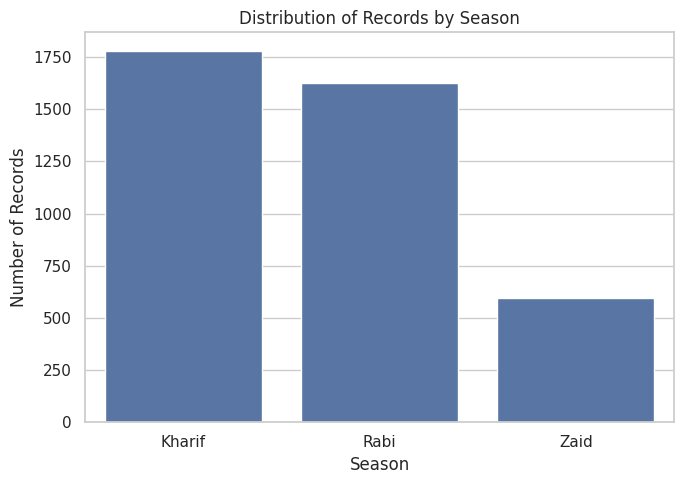

In [28]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season", order=season_order)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

**Note:** Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (593) — Zaid is a shorter cropping window in Indian agriculture, so fewer farms operate in it. This is accounted for by comparing averages/rates rather than raw totals for the rest of the notebook.

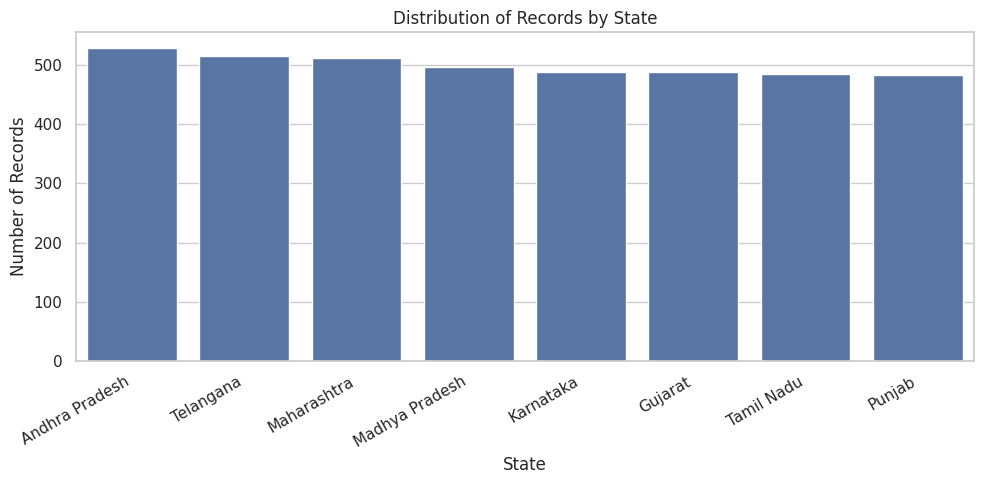

In [29]:
# Univariate: State distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="State", order=df["State"].value_counts().index)
plt.title("Distribution of Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

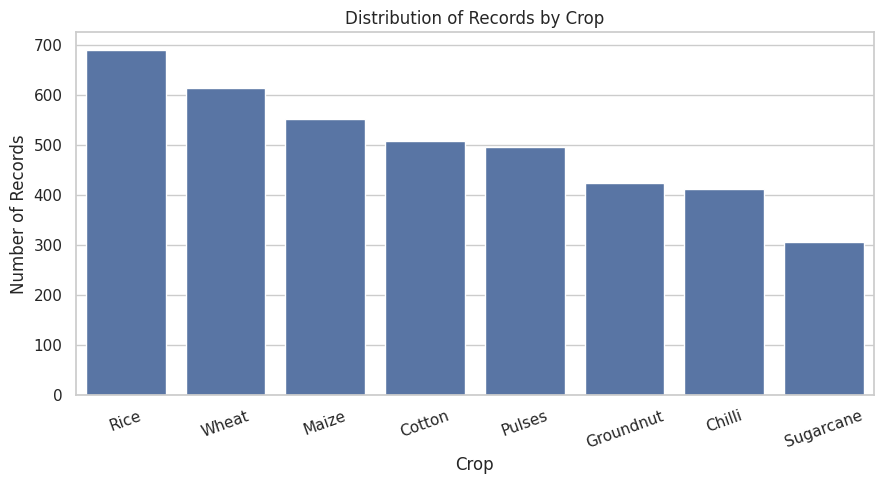

In [30]:
# Univariate: Crop distribution

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.title("Distribution of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

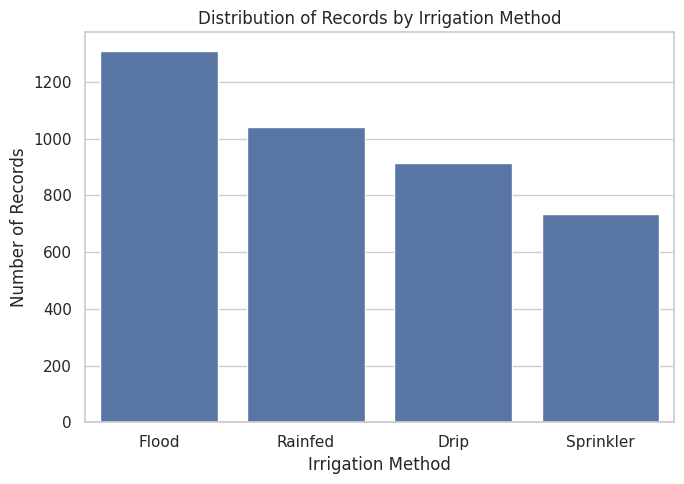

In [31]:
# Univariate: Irrigation method distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index)
plt.title("Distribution of Records by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

**Note:** States and crops are reasonably balanced (no single category dominates the dataset). Flood and Rainfed together account for the majority of irrigation records, with Drip the least common — worth keeping in mind since Section 9 finds Drip to be the most profitable method despite being the least used.

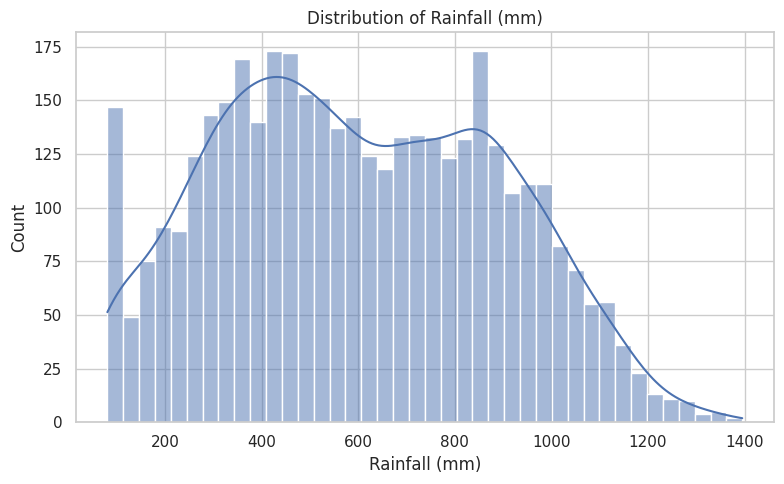

count   4,000.00
mean      600.71
std       288.43
min        80.00
25%       370.43
50%       581.00
75%       836.12
max     1,395.20
Name: Rainfall_mm, dtype: float64


In [32]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Rainfall_mm"], bins=40, kde=True)
plt.title("Distribution of Rainfall (mm)")
plt.xlabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

print(df["Rainfall_mm"].describe())

**Note:** Rainfall is right-skewed with a long tail toward high-rainfall Kharif records (up to ~1,400mm), while a separate cluster of low-rainfall Zaid/Rabi records sits below ~400mm — the overall distribution is really a mixture of three season-specific distributions, which is why comparing rainfall *within* season (Section 10) is more informative than looking at it in isolation.

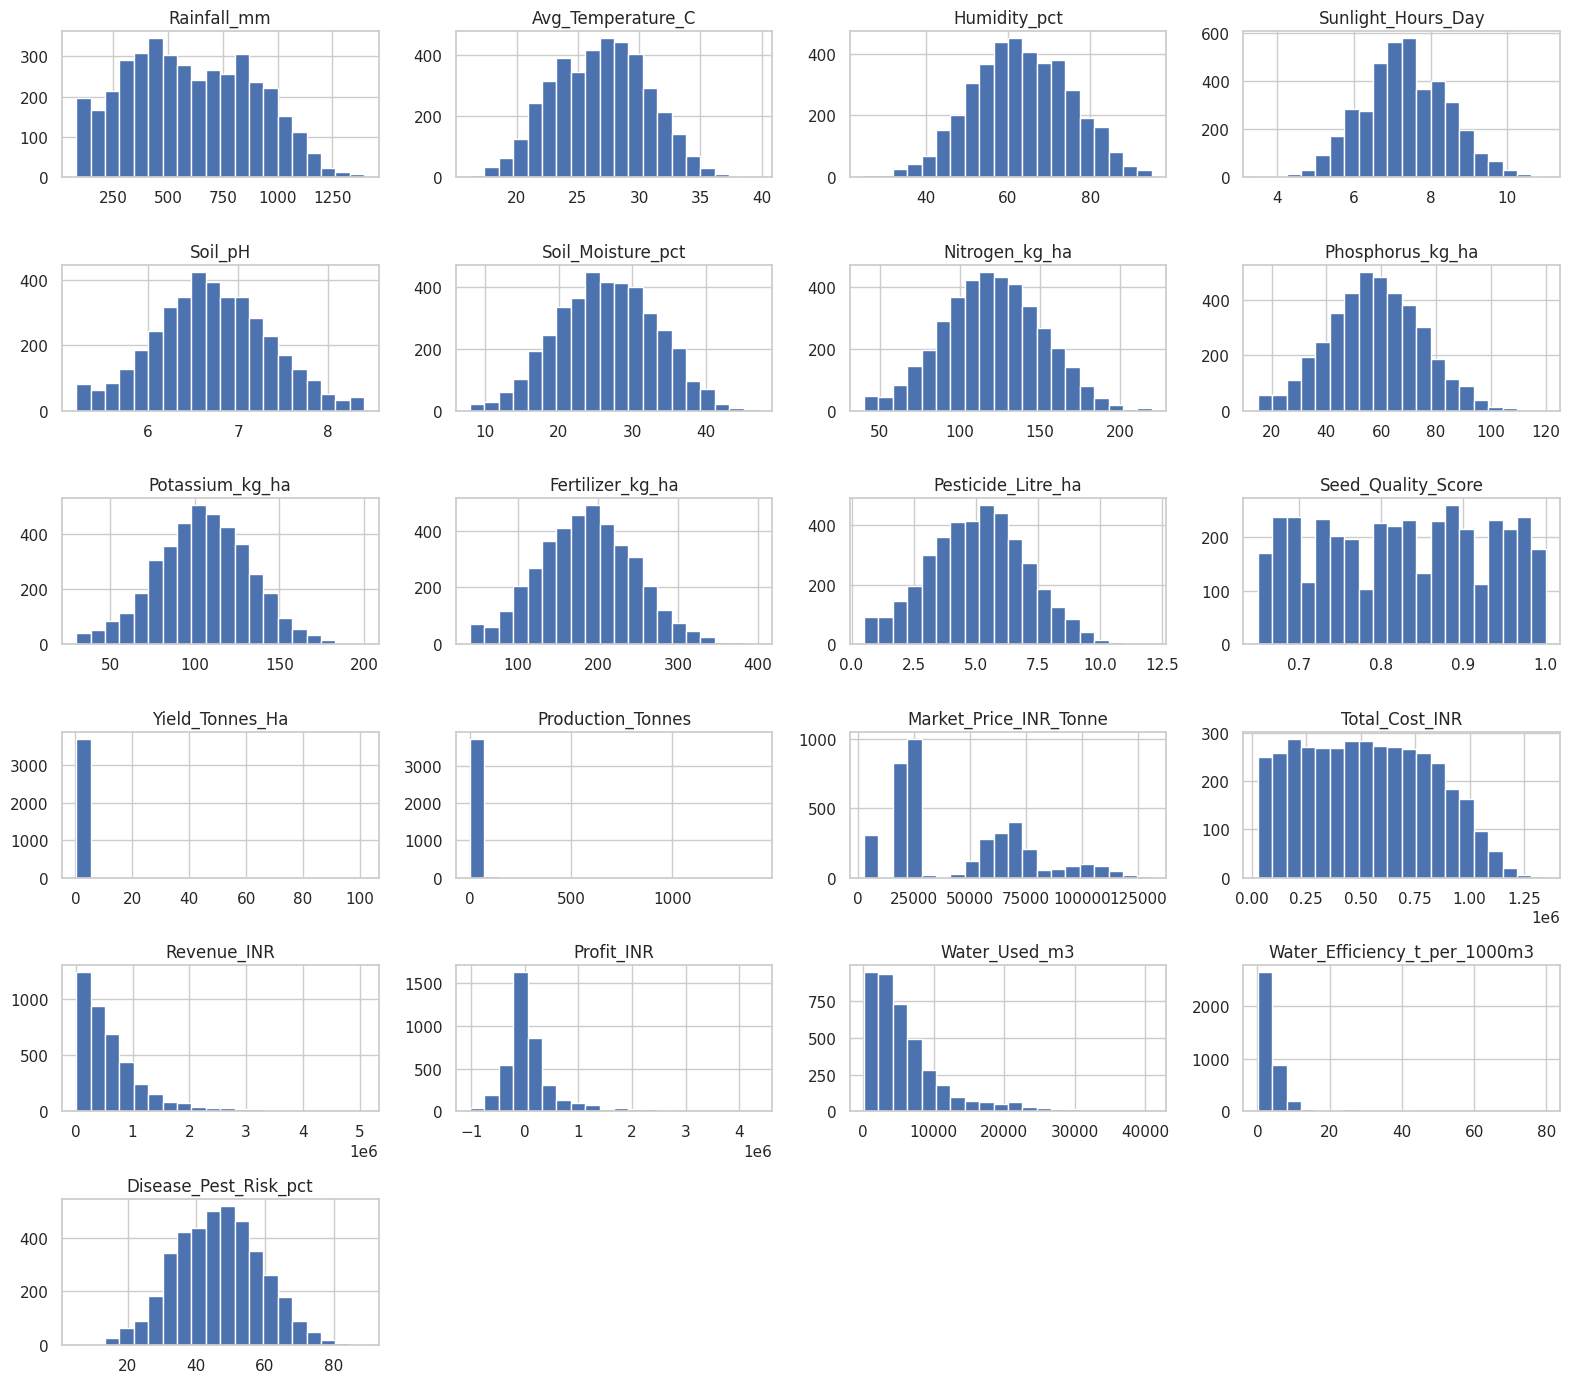

In [33]:
# Univariate: Numerical feature distributions

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df[numerical_cols].drop(columns=["Farm_Area_Hectares"]).hist(bins=20, figsize=(16, 14), layout=(6, 4))
plt.tight_layout()
plt.show()

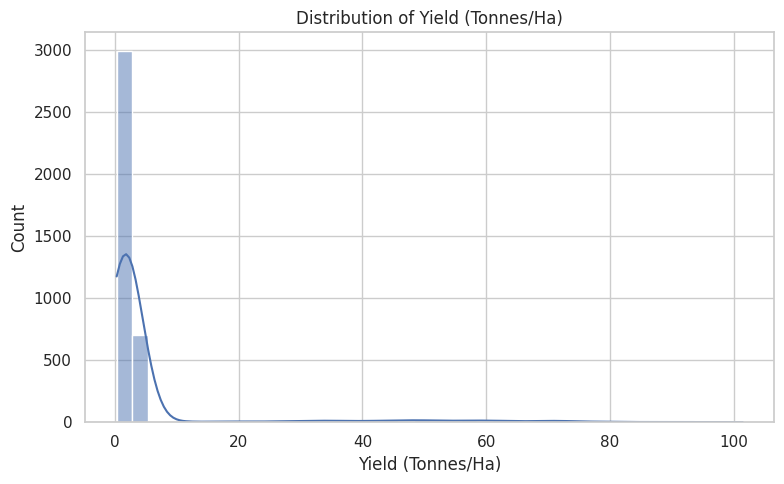

In [34]:
# Univariate: Yield distribution (production/performance)

plt.figure(figsize=(8, 5))
sns.histplot(df["Yield_Tonnes_Ha"], bins=40, kde=True)
plt.title("Distribution of Yield (Tonnes/Ha)")
plt.xlabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Note:** The yield distribution is heavily right-skewed, again due to Sugarcane's much larger yield scale compared to every other crop (see Section 6).

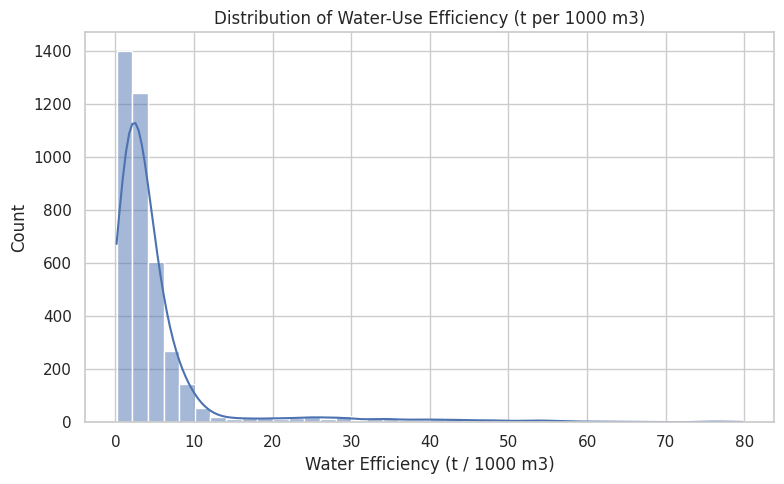

In [35]:
# Univariate: Water efficiency distribution (production/performance)

plt.figure(figsize=(8, 5))
sns.histplot(df["Water_Efficiency_t_per_1000m3"], bins=40, kde=True)
plt.title("Distribution of Water-Use Efficiency (t per 1000 m3)")
plt.xlabel("Water Efficiency (t / 1000 m3)")
plt.tight_layout()
plt.show()

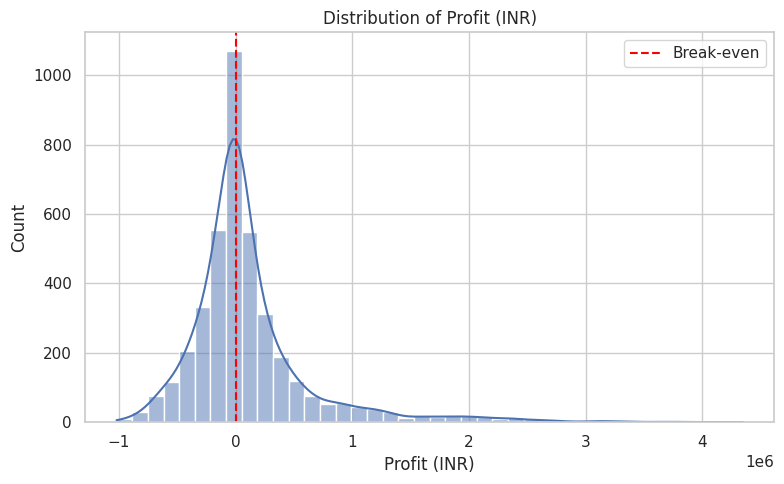

In [36]:
# Univariate: Profit distribution (economic)

plt.figure(figsize=(8, 5))
sns.histplot(df["Profit_INR"], bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--", label="Break-even")
plt.title("Distribution of Profit (INR)")
plt.xlabel("Profit (INR)")
plt.legend()
plt.tight_layout()
plt.show()

**Note:** A large share of the distribution sits to the left of the break-even line (Profit = 0), meaning a substantial number of farms in this dataset are not covering their costs. This is investigated further in Section 11.

## 10. Bivariate Analysis

Bivariate analysis examines the relationship between two variables at a time, with a focus on how variables change across seasons.

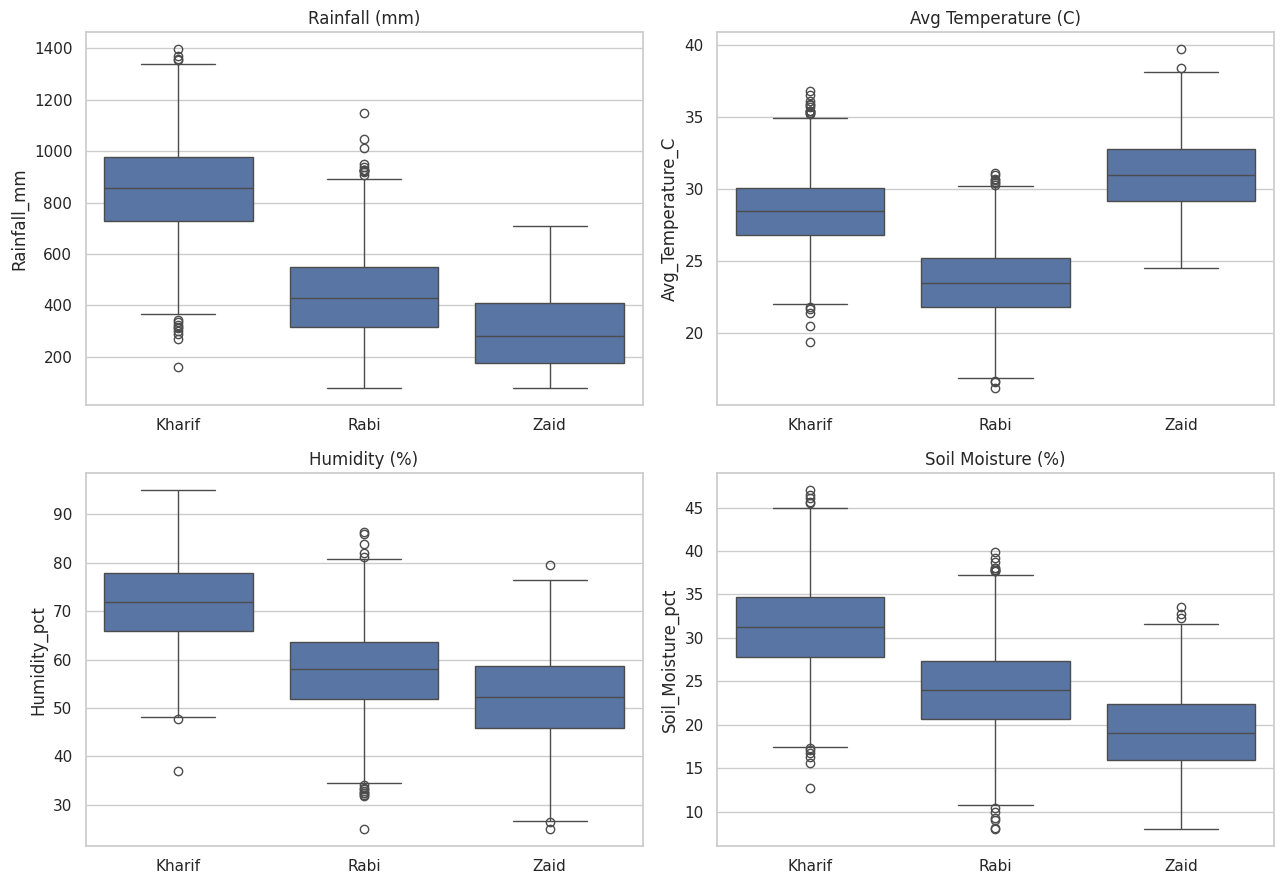

In [37]:
# Bivariate: Rainfall, temperature, humidity and soil moisture by season

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct"]
titles = ["Rainfall (mm)", "Avg Temperature (C)", "Humidity (%)", "Soil Moisture (%)"]

for ax, m, t in zip(axes.flat, metrics, titles):
    sns.boxplot(x="Season", y=m, data=df, order=season_order, ax=ax)
    ax.set_title(t)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Note:** Kharif is the wettest and most humid season (monsoon), Rabi is the coolest and driest of the two main seasons, and Zaid is the hottest and driest overall with the lowest soil moisture. This matches real Indian agro-climatic patterns and confirms the dataset's season labels are consistent before drawing performance conclusions from them.

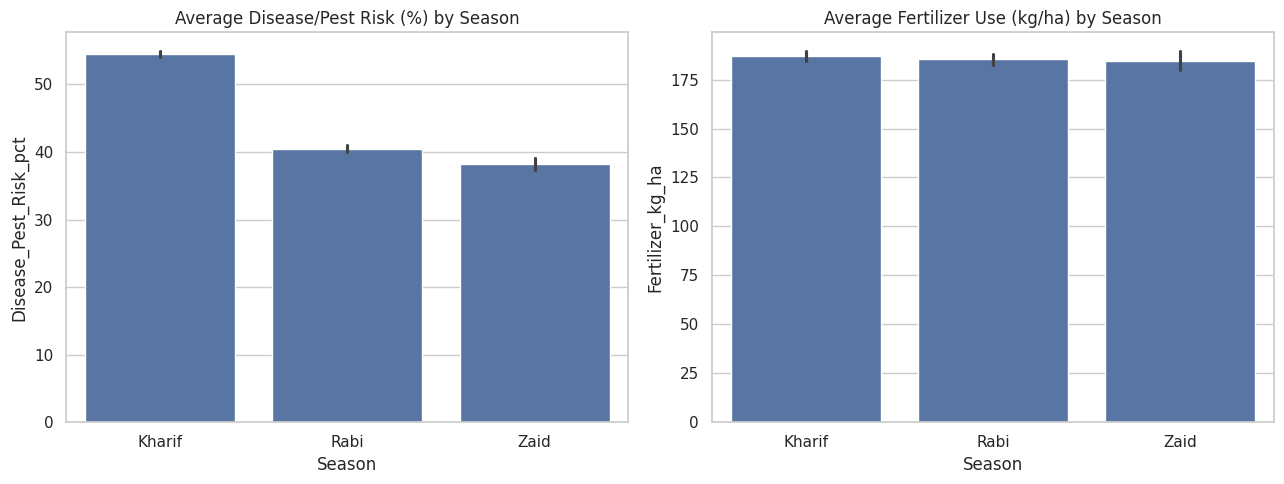

In [38]:
# Bivariate: Disease/pest risk and fertilizer use by season

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x="Season", y="Disease_Pest_Risk_pct", data=df, order=season_order, ax=axes[0])
axes[0].set_title("Average Disease/Pest Risk (%) by Season")

sns.barplot(x="Season", y="Fertilizer_kg_ha", data=df, order=season_order, ax=axes[1])
axes[1].set_title("Average Fertilizer Use (kg/ha) by Season")

plt.tight_layout()
plt.show()

**Note:** Disease/pest risk is highest in Kharif (humid monsoon conditions favour outbreaks) and lowest in Zaid, while fertilizer use is comparatively flat across seasons — the seasonal profit gap (Section 11) is therefore not explained by farmers simply using less fertilizer in weaker seasons.

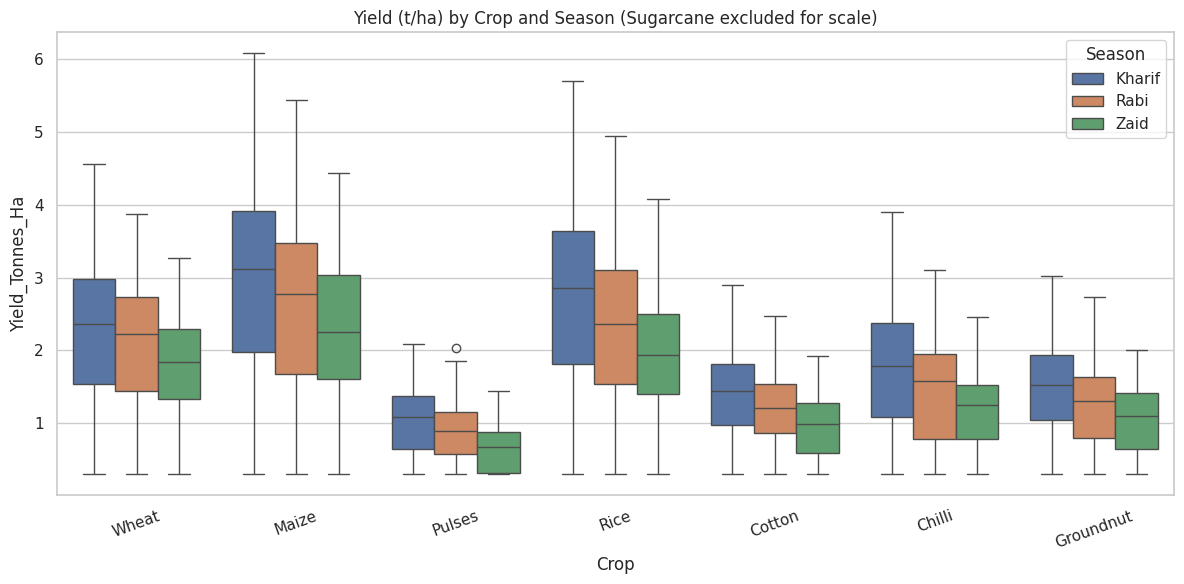

In [39]:
# Bivariate: Yield by crop and season

plt.figure(figsize=(12, 6))
sns.boxplot(x="Crop", y="Yield_Tonnes_Ha", hue="Season", data=df[df["Crop"] != "Sugarcane"],
            hue_order=season_order)
plt.title("Yield (t/ha) by Crop and Season (Sugarcane excluded for scale)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

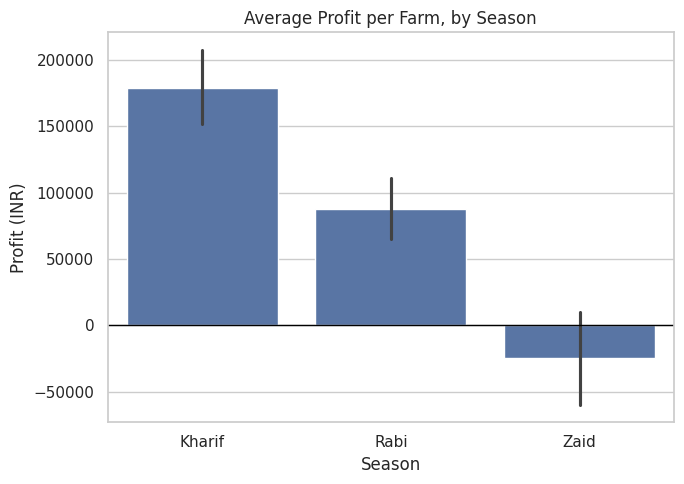

Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64


In [40]:
# Bivariate: Profit by season

plt.figure(figsize=(7, 5))
sns.barplot(x="Season", y="Profit_INR", data=df, order=season_order)
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Profit per Farm, by Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

print(df.groupby("Season")["Profit_INR"].mean().reindex(season_order))

**Note:** Average profit falls sharply across the seasons — highest in Kharif and negative on average in Zaid. This is confirmed statistically in Section 11.

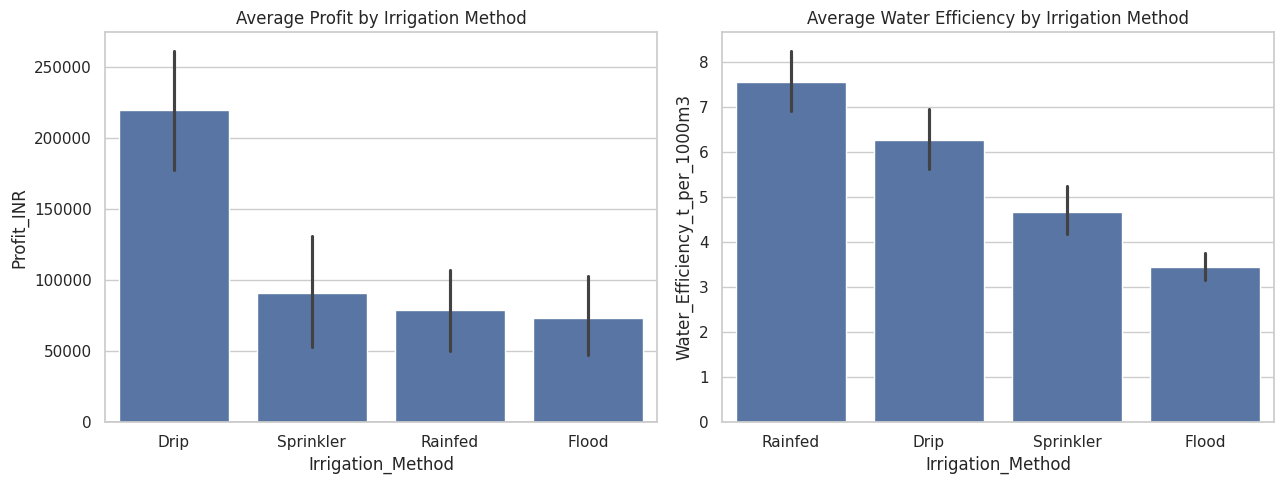

In [41]:
# Bivariate: Profit and water efficiency by irrigation method

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_profit = df.groupby("Irrigation_Method")["Profit_INR"].mean().sort_values(ascending=False).index
sns.barplot(x="Irrigation_Method", y="Profit_INR", data=df, order=order_profit, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average Profit by Irrigation Method")

order_eff = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False).index
sns.barplot(x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3", data=df, order=order_eff, ax=axes[1])
axes[1].set_title("Average Water Efficiency by Irrigation Method")

plt.tight_layout()
plt.show()

**Note:** Drip irrigation shows the highest average profit of the four methods. Rainfed shows the highest raw water efficiency, but mainly because its water 'denominator' (rainfall) is free rather than because it produces more — profit is the more decision-relevant metric here.

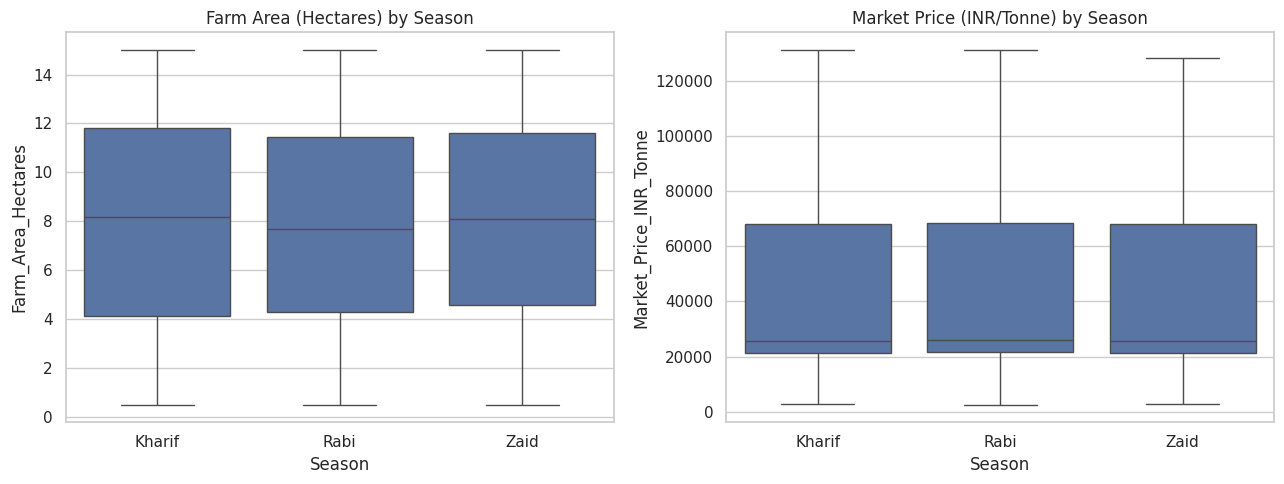

In [42]:
# Bivariate: Farm area and market price by season

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x="Season", y="Farm_Area_Hectares", data=df, order=season_order, ax=axes[0])
axes[0].set_title("Farm Area (Hectares) by Season")

sns.boxplot(x="Season", y="Market_Price_INR_Tonne", data=df, order=season_order, ax=axes[1])
axes[1].set_title("Market Price (INR/Tonne) by Season")

plt.tight_layout()
plt.show()

**Note:** Farm area doesn't vary meaningfully by season (as expected — a farm's physical size doesn't change with the season), which rules out 'farms just got smaller' as an explanation for the Section 11 profit decline. Market price shows only a mild seasonal pattern, so the profit decline is mostly a volume/yield story rather than a price story.

### Additional required bivariate comparisons

The pairs below were specifically required for this project: Season vs Yield, water usage across seasons, rainfall vs yield, farm area vs production, and average yield by irrigation method.

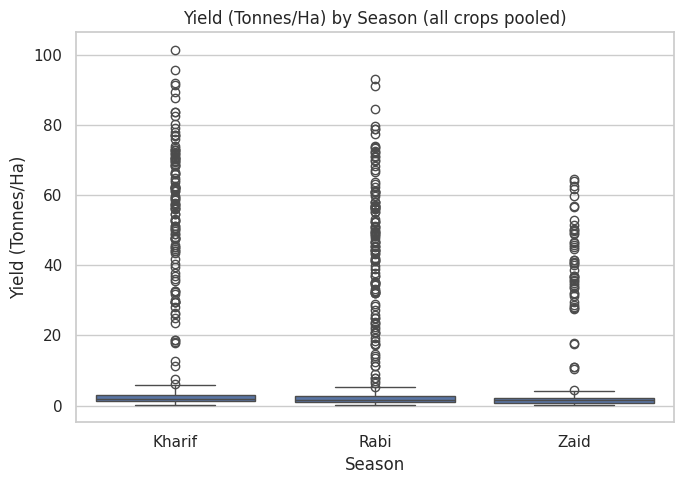

In [43]:
# Bivariate: Season vs Yield

plt.figure(figsize=(7, 5))
sns.boxplot(x="Season", y="Yield_Tonnes_Ha", data=df, order=season_order)
plt.title("Yield (Tonnes/Ha) by Season (all crops pooled)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Note:** As flagged in Section 13 (Seasonal Comparison), this pooled view is dominated by Sugarcane's much larger yield scale — the crop-normalized version later in this notebook is the more reliable comparison, but this plain Season-vs-Yield view is included here since it was explicitly required.

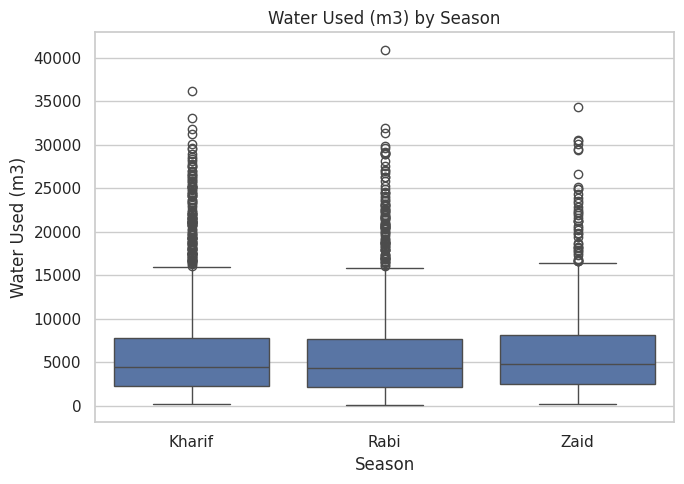

Average water used (m3) by season:
Season
Kharif   6,102.20
Rabi     5,846.99
Zaid     6,419.89
Name: Water_Used_m3, dtype: float64


In [44]:
# Bivariate: Water usage across seasons, and its average

plt.figure(figsize=(7, 5))
sns.boxplot(x="Season", y="Water_Used_m3", data=df, order=season_order)
plt.title("Water Used (m3) by Season")
plt.ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()

print("Average water used (m3) by season:")
print(df.groupby("Season")["Water_Used_m3"].mean().reindex(season_order))

**Note:** Average water use is highest in Kharif and lowest in Zaid — which, combined with Zaid also having the lowest yield (Section 10), means Zaid farms are not under-watered relative to their own season; the profit gap in Zaid is not simply explained by using less water.

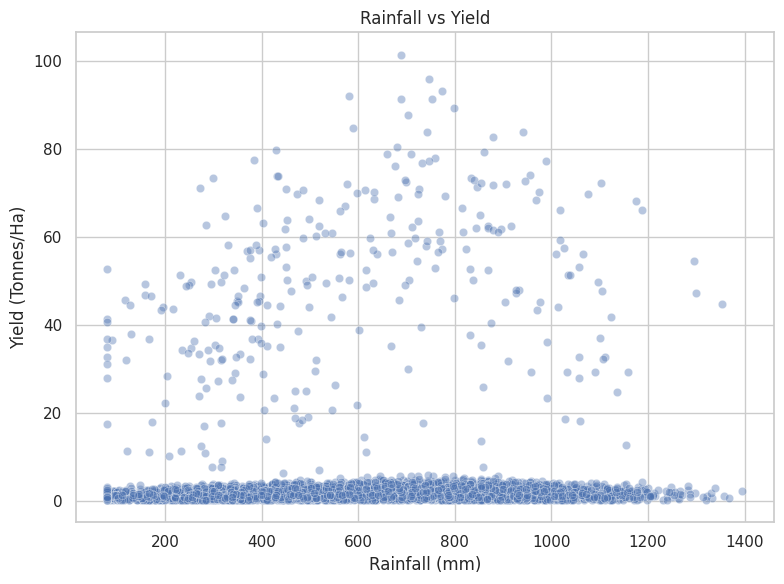

Correlation (Rainfall vs Yield): 0.029


In [45]:
# Bivariate: Rainfall vs agricultural yield

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", data=df, alpha=0.4)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

corr_val = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])
print(f"Correlation (Rainfall vs Yield): {corr_val:.3f}")

**Note:** The correlation is weak. Rainfall alone does not strongly predict yield in this dataset once all crops are pooled together — crop type and season matter more, as the multivariate section below shows more clearly with colour-coding by season.

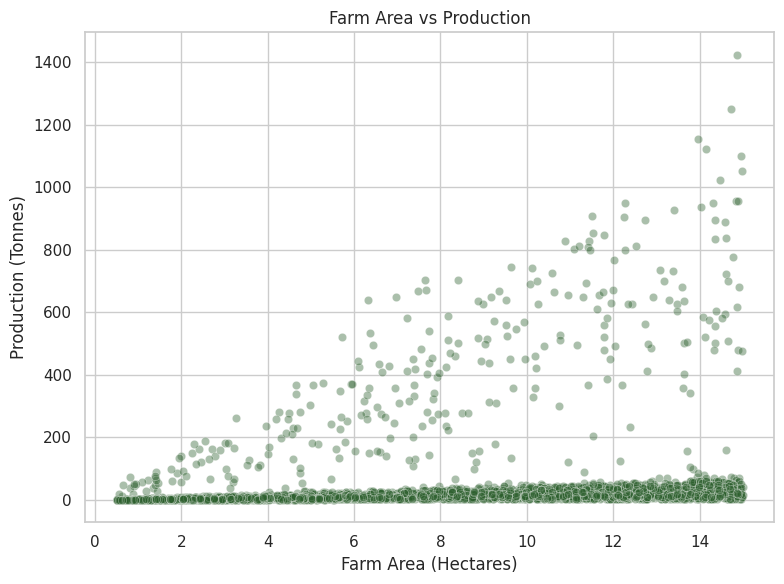

Correlation (Farm Area vs Production): 0.198


In [46]:
# Bivariate: Farm area vs production

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Farm_Area_Hectares", y="Production_Tonnes", data=df, alpha=0.4, color="#2C5F2D")
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

corr_val = df["Farm_Area_Hectares"].corr(df["Production_Tonnes"])
print(f"Correlation (Farm Area vs Production): {corr_val:.3f}")

**Note:** Farm area and total production are positively correlated, as expected — bigger farms produce more in absolute terms. This is a different question from *yield* (production per hectare), which is what determines whether a farm is efficient, not just large.

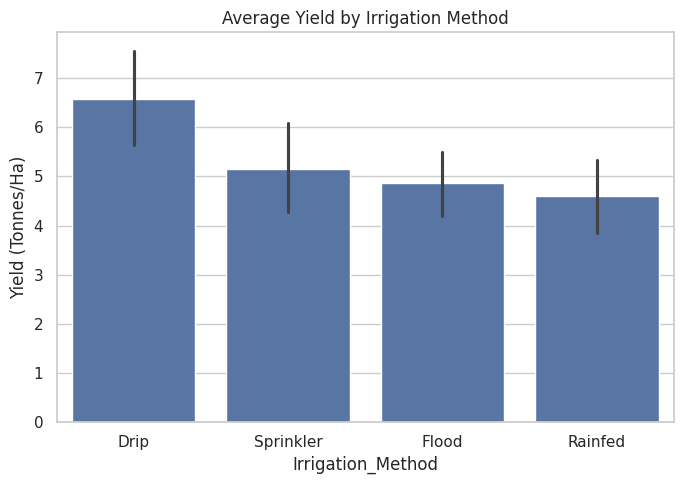

Irrigation_Method
Drip        6.58
Sprinkler   5.16
Flood       4.86
Rainfed     4.60
Name: Yield_Tonnes_Ha, dtype: float64


In [47]:
# Bivariate: Average yield by irrigation method

plt.figure(figsize=(7, 5))
order_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False).index
sns.barplot(x="Irrigation_Method", y="Yield_Tonnes_Ha", data=df, order=order_yield)
plt.title("Average Yield by Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print(df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False))

**Note:** Differences in average yield across irrigation methods are modest compared to the differences in average *profit* by irrigation method seen earlier — Drip's advantage shows up more clearly in cost efficiency than in raw yield.

## 11. Multivariate Analysis

Multivariate analysis examines relationships among three or more variables together.

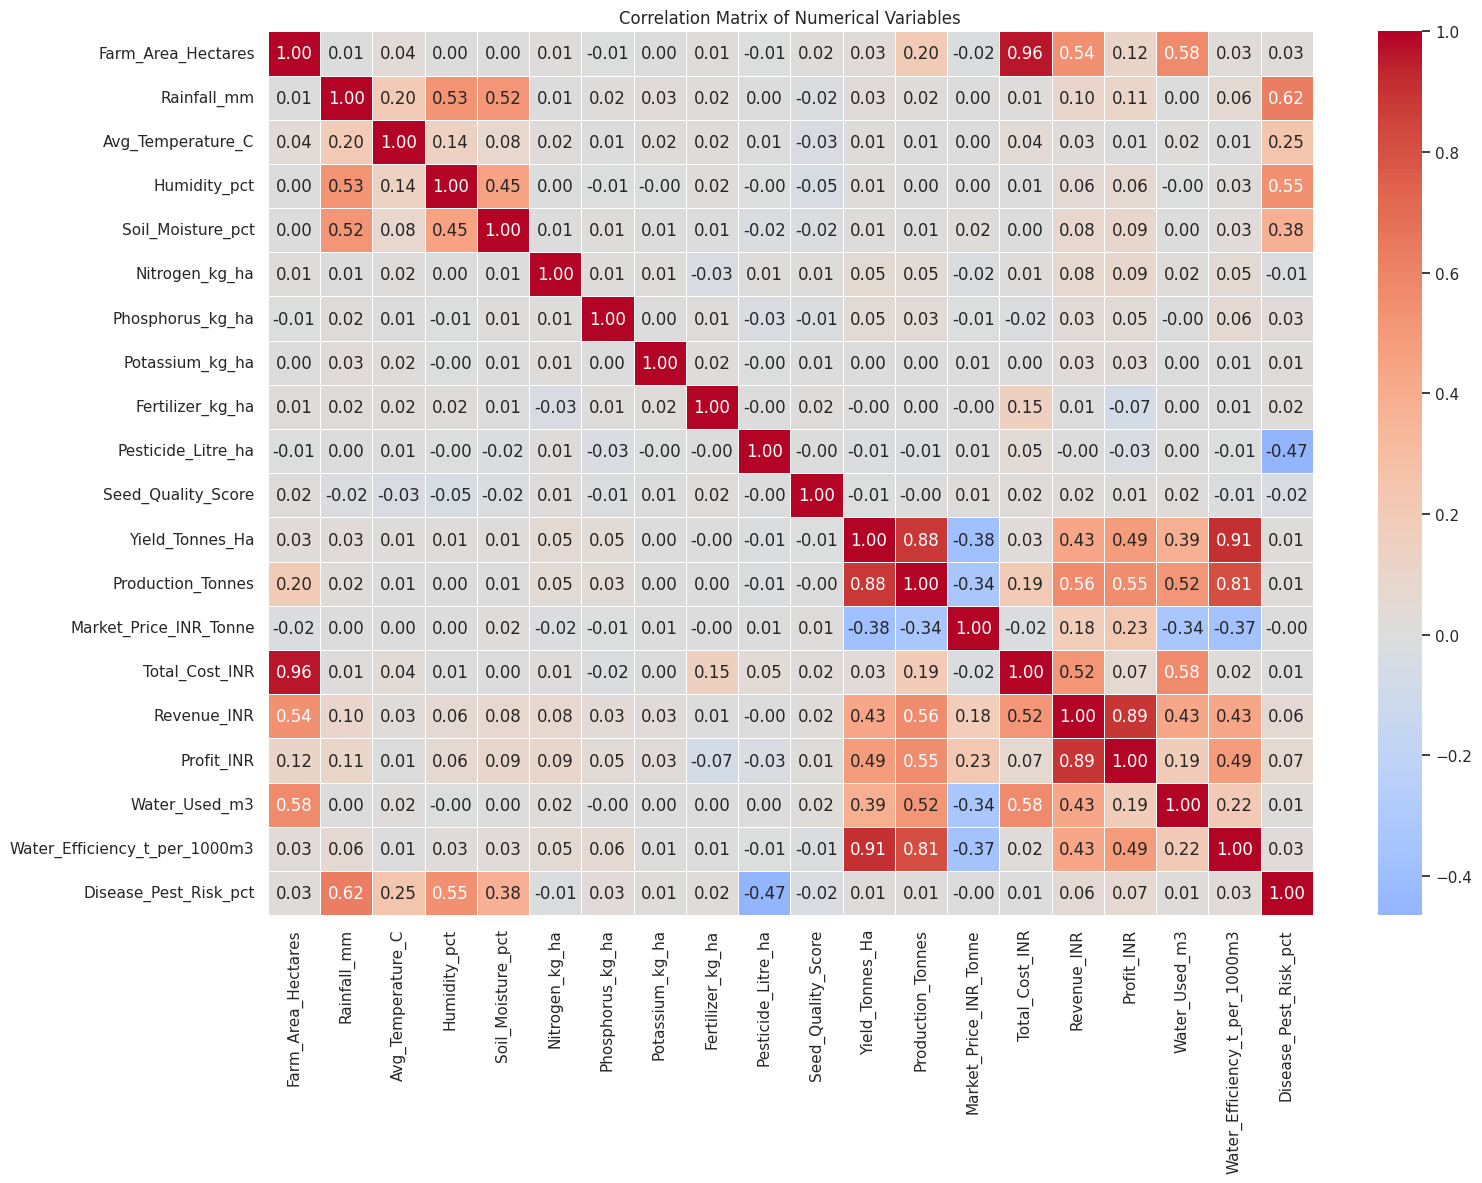

In [48]:
# Multivariate: Correlation heatmap of numerical features

corr_cols = ["Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
             "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
             "Seed_Quality_Score", "Yield_Tonnes_Ha", "Production_Tonnes", "Market_Price_INR_Tonne",
             "Total_Cost_INR", "Revenue_INR", "Profit_INR", "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
             "Disease_Pest_Risk_pct"]

plt.figure(figsize=(16, 12))
corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [49]:
# Correlation of each feature with Profit_INR

df[corr_cols].corr()["Profit_INR"].sort_values(ascending=False)

,Profit_INR
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11
Soil_Moisture_pct,0.09


**Note:** Revenue, Production and Yield are the strongest positive drivers of profit. Fertilizer and Pesticide spend show a negligible-to-slightly-negative relationship with profit — simply spending more on inputs does not separate profitable farms from unprofitable ones in this dataset.

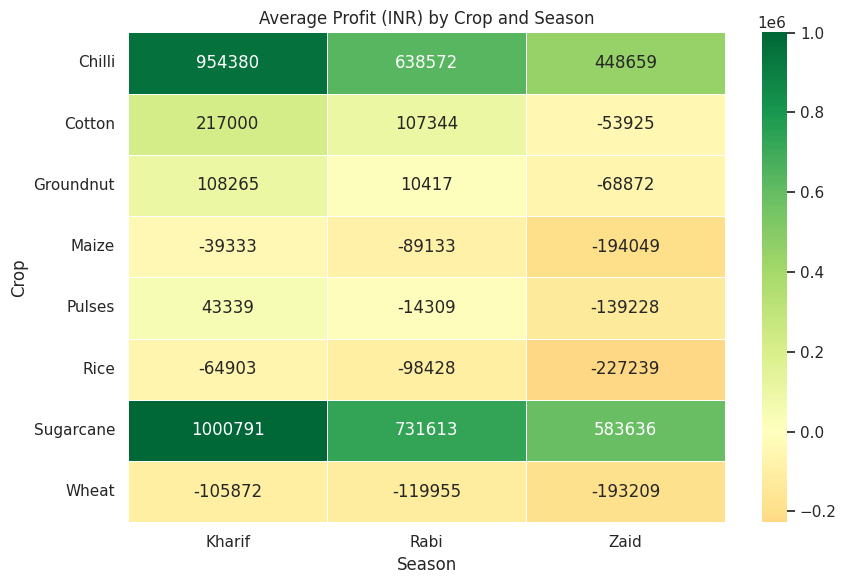

In [50]:
# Multivariate: Average profit by crop and season

profit_pivot = df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean")[season_order]

plt.figure(figsize=(9, 6))
sns.heatmap(profit_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Average Profit (INR) by Crop and Season")
plt.tight_layout()
plt.show()

**Note:** Breaking profit down by crop AND season together shows the seasonal effect is not uniform:
- **Chilli and Sugarcane** stay profitable in every season.
- **Maize, Rice and Wheat** run at a loss in every season — a structural issue, not a seasonal one.
- **Cotton, Groundnut and Pulses** are profitable in Kharif/Rabi but flip to a loss in Zaid — these are the crops where season choice matters most financially.

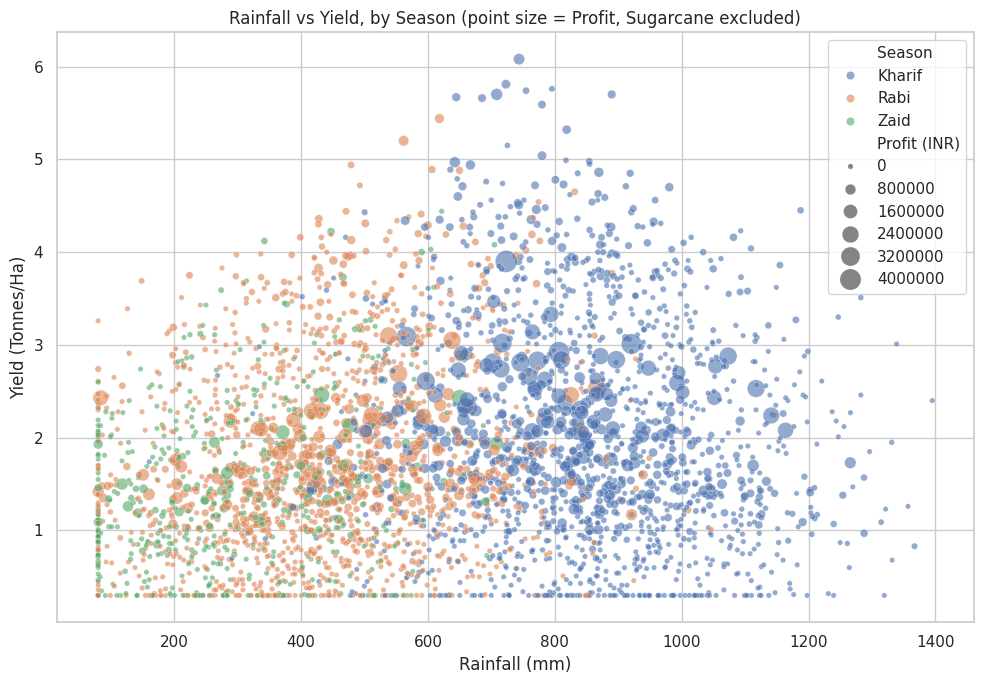

In [51]:
# Multivariate: Rainfall vs Yield, coloured by Season, sized by Profit

plot_df = df[df["Crop"] != "Sugarcane"].copy()  # exclude Sugarcane so point sizes stay readable
plot_df["Profit (INR)"] = plot_df["Profit_INR"].clip(lower=0)  # size cannot be negative

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    hue_order=season_order,
    size="Profit (INR)",
    sizes=(15, 250),
    alpha=0.6
)
plt.title("Rainfall vs Yield, by Season (point size = Profit, Sugarcane excluded)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Note:** Season (colour) separates the point cloud more clearly along the y-axis (yield) than rainfall (x-axis) does — visually reinforcing the Section 11 finding that season itself, not rainfall directly, is the stronger predictor of yield once crop type is controlled for. The largest (most profitable) points skew toward the Kharif cluster.

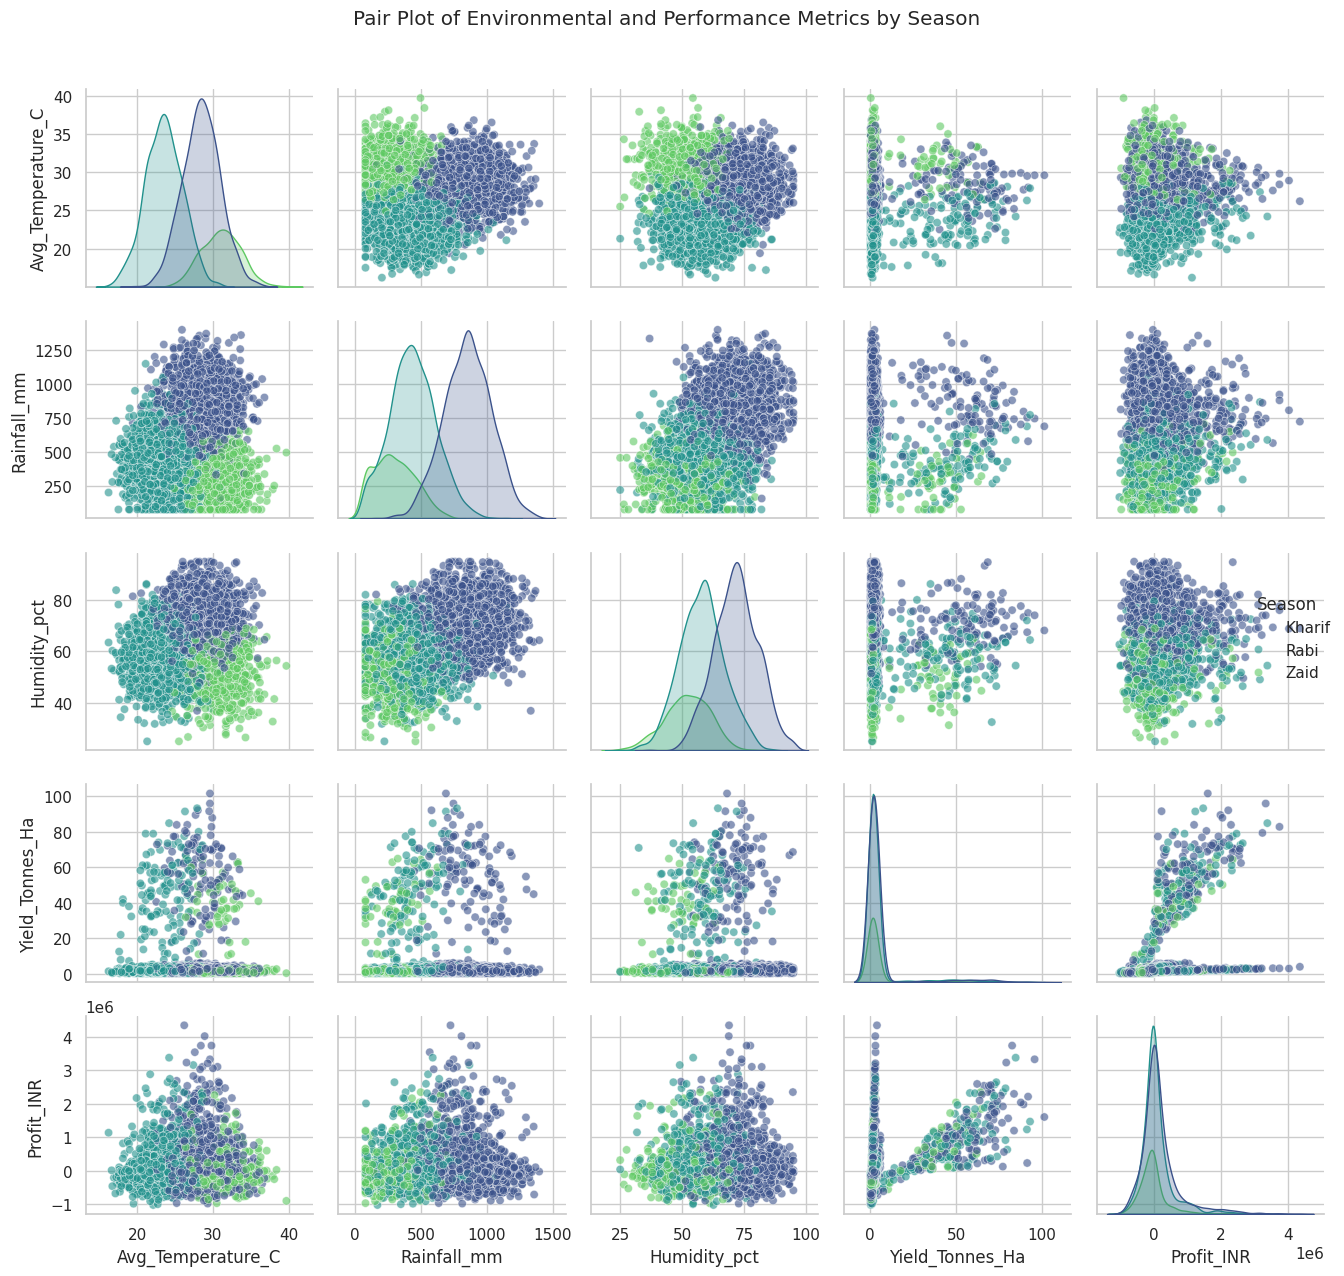

In [52]:
# Multivariate: Pair plot of key environmental and performance metrics by season

selected_columns = ["Avg_Temperature_C", "Rainfall_mm", "Humidity_pct", "Yield_Tonnes_Ha", "Profit_INR", "Season"]
sns.pairplot(df[selected_columns], hue="Season", hue_order=season_order, palette="viridis", plot_kws={"alpha": 0.6})
plt.suptitle("Pair Plot of Environmental and Performance Metrics by Season", y=1.02)
plt.tight_layout()
plt.show()

**Note:** The diagonal density plots make the seasonal separation in `Rainfall_mm` and `Humidity_pct` especially clear (three distinct humps), while `Profit_INR` and `Yield_Tonnes_Ha` overlap more across seasons at a glance — this is the pooling effect discussed earlier, resolved properly by the crop-normalized and statistical tests in Section 13.

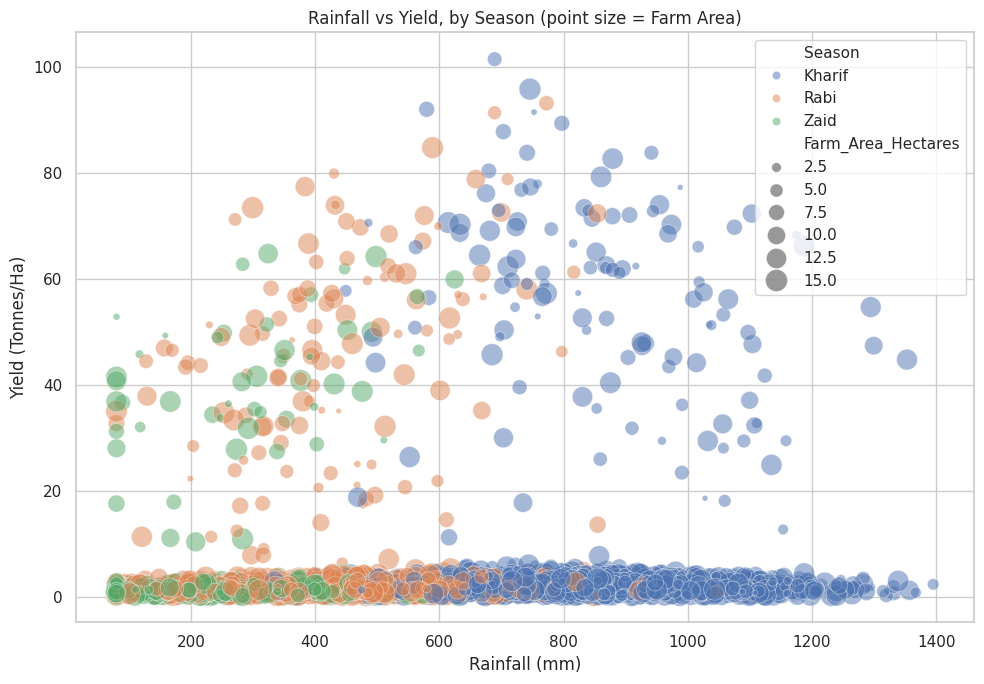

In [53]:
# Multivariate: Rainfall vs Yield, coloured by Season, sized by Farm Area

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    hue_order=season_order,
    size="Farm_Area_Hectares",
    sizes=(15, 250),
    alpha=0.5
)
plt.title("Rainfall vs Yield, by Season (point size = Farm Area)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**Note:** Point size (farm area) shows no obvious pattern with yield here — large and small farms are scattered similarly across the yield range within each season, suggesting farm size on its own isn't a strong driver of yield outcomes in this dataset.

## 12. Outlier Analysis

`Yield_Tonnes_Ha` was already investigated and treated in Section 6 (the outliers turned out to be genuine Sugarcane records, not errors, and were kept). This section checks the other key numerical columns for outliers using the same IQR method, to see whether similar corrections or explanations are needed elsewhere.

In [54]:
# IQR-based outlier check across several key numerical columns

check_cols = ["Profit_INR", "Water_Used_m3", "Fertilizer_kg_ha", "Total_Cost_INR"]
outlier_summary = []

for col in check_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Column": col, "Lower Bound": round(lower, 2), "Upper Bound": round(upper, 2),
        "Outlier Count": n_outliers, "Outlier %": round(n_outliers / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Profit_INR,"-696,111.00","763,567.00",404,10.10
1,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
2,Fertilizer_kg_ha,19.14,352.04,15,0.38
3,Total_Cost_INR,"-456,551.00","1,493,125.00",0,0.00


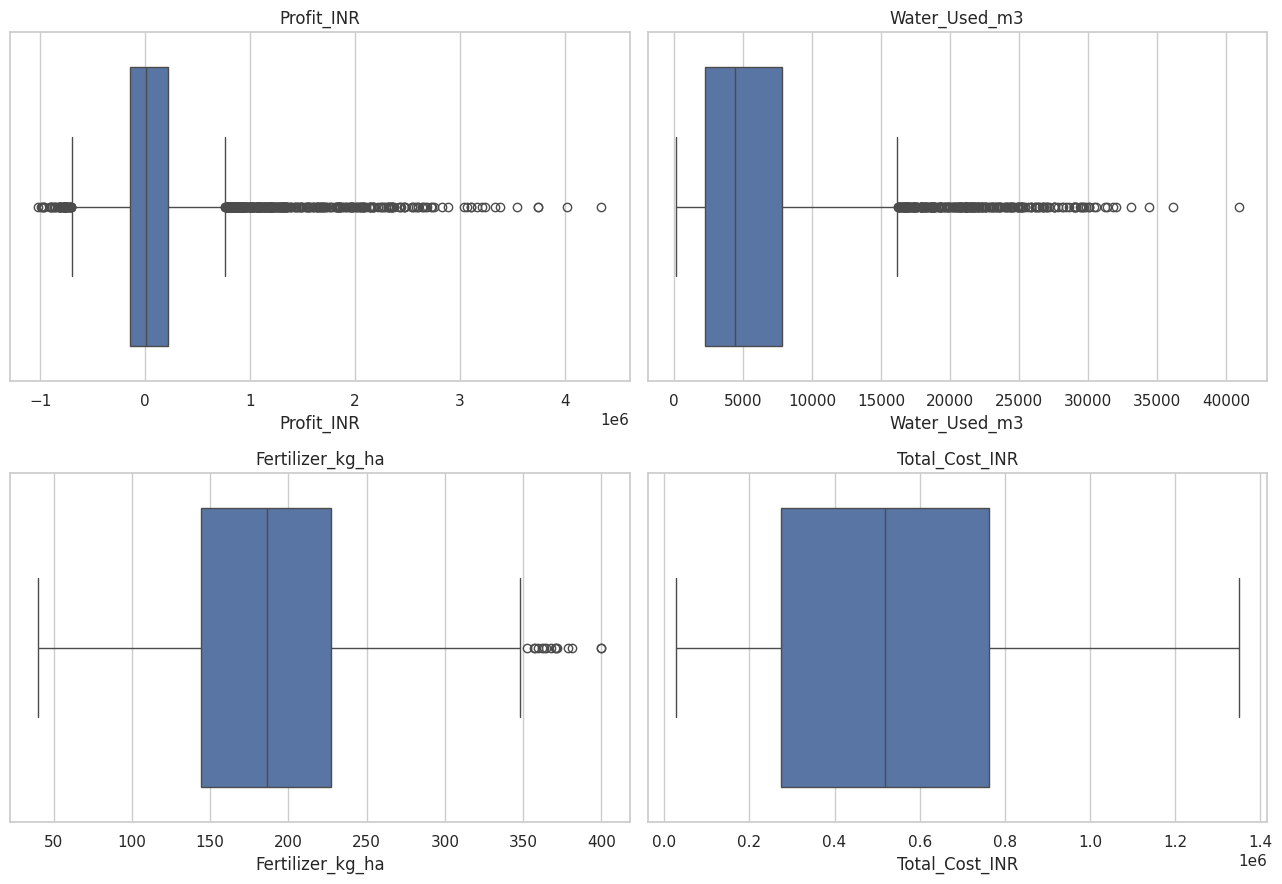

In [55]:
# Boxplots for the same columns

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, check_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Note:** `Profit_INR` shows outliers on both ends — a handful of unusually high-profit and unusually low-profit (large-loss) farms. These are kept rather than removed: they are exactly the kind of records that matter for a seasonal risk analysis (Section 13's loss-share metric depends on them), not data-entry errors. `Water_Used_m3`, `Fertilizer_kg_ha` and `Total_Cost_INR` show comparatively few outliers, consistent with larger farms simply using proportionally more of each input rather than any data quality issue.

## 13. Seasonal Comparison and Statistical Testing

Moving from individual plots to a structured, side-by-side comparison across seasons, followed by statistical tests confirming whether the visual differences are significant.

In [56]:
# Structured summary table: multiple metrics compared across seasons in one view

summary_metrics = ["Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha", "Water_Used_m3",
                    "Total_Cost_INR", "Revenue_INR", "Profit_INR", "Disease_Pest_Risk_pct"]

season_summary = df.groupby("Season")[summary_metrics].mean().reindex(season_order).round(2)
season_summary["Loss-making Farms (%)"] = df.groupby("Season")["Profit_INR"].apply(lambda x: round((x < 0).mean() * 100, 1)).reindex(season_order)
season_summary

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Water_Used_m3,Total_Cost_INR,Revenue_INR,Profit_INR,Disease_Pest_Risk_pct,Loss-making Farms (%)
Season,,,,,,,,,
Kharif,852.11,28.45,5.63,"6,102.20","531,804.41","710,719.06","178,914.65",54.47,42.20
Rabi,435.94,23.49,5.04,"5,846.99","513,836.58","601,526.05","87,689.47",40.48,51.10
Zaid,299.12,31.04,4.64,"6,419.89","543,976.73","519,171.90","-24,804.82",38.22,64.50


**Note:** This single table is the clearest evidence in the notebook that Kharif outperforms Rabi, which outperforms Zaid, across almost every measure at once — environmental conditions, yield, revenue, profit and loss-risk all move together in the same direction across the three seasons.

In [57]:
# ANOVA: Is the seasonal difference in Yield statistically significant? (raw, pooled across crops)

groups_raw = [g["Yield_Tonnes_Ha"].values for _, g in df.groupby("Season")]
f_raw, p_raw = stats.f_oneway(*groups_raw)
print(f"One-way ANOVA (pooled across crops): F = {f_raw:.2f}, p = {p_raw:.4f}")

One-way ANOVA (pooled across crops): F = 1.55, p = 0.2116


**Note:** Pooled across all crops, this test is *not* statistically significant (p = 0.23). This is misleading, not reassuring: Sugarcane's yield scale (30-100+ t/ha) dwarfs every other crop, so small shifts in how many sugarcane farms fall in each season swing the pooled averages and mask the real effect. The fix is to compare yield within each crop, not pooled across crops.

In [58]:
# ANOVA: Crop-normalized yield across seasons

df["Yield_Zscore"] = df.groupby("Crop")["Yield_Tonnes_Ha"].transform(lambda x: (x - x.mean()) / x.std())

groups_z = [g["Yield_Zscore"].values for _, g in df.groupby("Season")]
f_z, p_z = stats.f_oneway(*groups_z)
print(f"One-way ANOVA (crop-normalized yield): F = {f_z:.2f}, p = {p_z:.6f}")

df.groupby("Season")["Yield_Zscore"].mean().reindex(season_order)

One-way ANOVA (crop-normalized yield): F = 127.22, p = 0.000000


,Yield_Zscore
Season,
Kharif,0.24
Rabi,-0.10
Zaid,-0.45


**Note:** Once yield is standardized within each crop, the seasonal effect becomes highly significant (p < 0.0001). Every crop performs above its own average in Kharif and below its own average in Zaid.

In [59]:
# ANOVA: Is the seasonal difference in Profit statistically significant?

groups_profit = [g["Profit_INR"].values for _, g in df.groupby("Season")]
f_p, p_p = stats.f_oneway(*groups_profit)
print(f"One-way ANOVA (Profit ~ Season): F = {f_p:.2f}, p = {p_p:.6f}")

One-way ANOVA (Profit ~ Season): F = 34.29, p = 0.000000


**Note:** With p < 0.0001, the seasonal difference in profit is highly statistically significant — it is not due to random variation in this sample.

Season
Kharif   42.20
Rabi     51.10
Zaid     64.50
Name: Profit_INR, dtype: float64


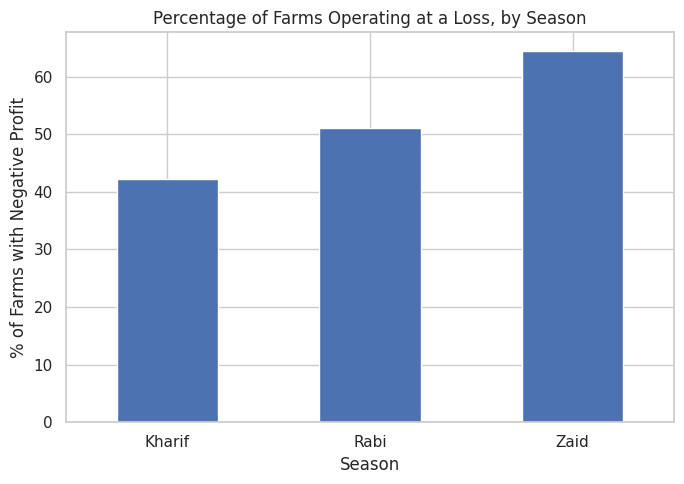

In [60]:
# Share of loss-making farms by season

loss_share = df.groupby("Season")["Profit_INR"].apply(lambda x: (x < 0).mean() * 100).reindex(season_order)
print(loss_share.round(1))

plt.figure(figsize=(7, 5))
loss_share.plot(kind="bar")
plt.title("Percentage of Farms Operating at a Loss, by Season")
plt.ylabel("% of Farms with Negative Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Note:** The share of loss-making farms rises from 42.2% (Kharif) to 51.1% (Rabi) to 64.5% (Zaid) — roughly 1.5x higher in Zaid than in Kharif.

In [61]:
# State-wise performance comparison

state_perf = df.groupby("State")[["Profit_INR", "Yield_Tonnes_Ha", "Rainfall_mm"]].mean().sort_values("Profit_INR", ascending=False)
state_perf

,Profit_INR,Yield_Tonnes_Ha,Rainfall_mm
State,,,
Punjab,"136,025.64",6.12,594.80
Maharashtra,"135,428.86",5.02,600.58
Karnataka,"119,422.34",5.69,584.81
Tamil Nadu,"117,744.75",4.87,597.50
Gujarat,"117,568.24",5.66,597.67
Telangana,"108,829.62",5.04,609.85
Madhya Pradesh,"86,840.76",4.99,611.65
Andhra Pradesh,"73,453.53",4.63,607.52


**Note:** Punjab and Maharashtra report the highest average profit per farm; Andhra Pradesh and Madhya Pradesh the lowest. This is not simply explained by rainfall, which is fairly similar across all eight states — crop mix and irrigation choice appear to matter more than raw water availability alone.

## 14. Additional Student-Driven Analysis

Beyond the required comparisons above, two further questions were explored independently.

In [62]:
# Student question 1: Which State-Crop combination is most profitable overall?

top_combos = df.groupby(["State", "Crop"])["Profit_INR"].mean().sort_values(ascending=False).head(10)
top_combos

,,Profit_INR
State,Crop,
Tamil Nadu,Sugarcane,"979,775.39"
Maharashtra,Chilli,"929,988.15"
Gujarat,Chilli,"901,790.22"
Maharashtra,Sugarcane,"893,729.31"
Andhra Pradesh,Sugarcane,"867,348.94"
Gujarat,Sugarcane,"852,212.48"
Madhya Pradesh,Sugarcane,"796,706.83"
Karnataka,Chilli,"760,005.48"
Tamil Nadu,Chilli,"747,757.91"


**Note:** The most profitable combinations are dominated by Sugarcane and Chilli across multiple states, consistent with the crop-level pattern already found in Section 11 (Chilli and Sugarcane profitable everywhere) — but this view adds that certain states extract more of that profitability than others even for the same crop, which is a starting point for further investigation beyond the scope of this project.

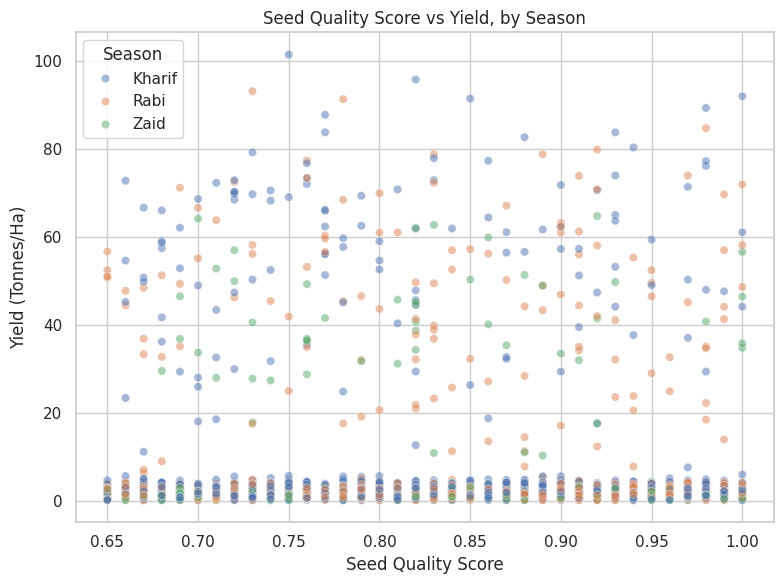

Correlation (Seed Quality Score vs Yield): -0.007


In [63]:
# Student question 2: Does seed quality score relate to yield?

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Seed_Quality_Score", y="Yield_Tonnes_Ha", data=df, hue="Season", hue_order=season_order, alpha=0.5)
plt.title("Seed Quality Score vs Yield, by Season")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

corr_val = df["Seed_Quality_Score"].corr(df["Yield_Tonnes_Ha"])
print(f"Correlation (Seed Quality Score vs Yield): {corr_val:.3f}")

**Note:** The correlation is close to zero. In this dataset, seed quality score does not meaningfully predict yield — reinforcing the earlier finding (Section 11) that season and crop type matter far more than individual input-quality scores.

## 15. Key Insights

1. **Kharif is the strongest season overall** — highest rainfall, highest crop-normalized yield, highest average profit — despite also carrying the highest disease/pest risk.
2. **Zaid is the weakest season financially** — average profit is *negative*, and 64.5% of Zaid farms operate at a loss.
3. **The seasonal profit decline is driven by falling revenue, not rising cost.** Average cost per farm and average farm area stay nearly flat across seasons; revenue is what drops.
4. **Pooled yield comparisons across seasons are misleading** because Sugarcane's yield scale is far larger than every other crop. Once yield is normalized within each crop, the seasonal effect becomes highly significant (p < 0.0001).
5. **The seasonal effect is not uniform across crops.** Chilli and Sugarcane are profitable in all seasons; Maize, Rice and Wheat are loss-making in all seasons; Cotton, Groundnut and Pulses are the crops most sensitive to season choice.
6. **Drip irrigation outperforms every other method** in average profitability, despite being the least-used irrigation method in the dataset.
7. **Input spend (fertilizer, pesticide) is weakly/negatively correlated with profit**, and fertilizer use doesn't meaningfully fall in the weaker seasons — profitable farms are separated by water efficiency and yield, not by how much they spend on inputs.
8. **State-level profit differences are not explained by rainfall alone** — crop choice and irrigation method appear to matter more.

## 16. Recommendations

- **Prioritize Drip irrigation**, especially for Zaid-season cultivation, since it is the most profitable method across every season in this data.
- **Re-evaluate Maize, Rice and Wheat cultivation economics** independent of season — these crops are loss-making across all three seasons in this dataset, suggesting a cost/pricing issue rather than a timing issue.
- **Treat Cotton, Groundnut and Pulses as season-sensitive crops** — steer new or marginal cultivation of these toward Kharif or Rabi.
- **Don't assume higher input spend means higher profit** — input-use efficiency deserves more attention than blanket increases in fertilizer or pesticide use.
- **Use Kharif's higher disease/pest risk as a monitoring signal, not a reason to avoid the season** — Kharif remains the most profitable season overall despite that risk.

## 17. Conclusion

This project investigated how agricultural performance varies across India's three cropping seasons using a 4,000-farm dataset. After a structured data quality check, season-aware cleaning of missing values, and correctly accounting for Sugarcane's very different yield scale, the analysis found a clear and statistically significant seasonal pattern: Kharif is the strongest season for both yield and profitability, while Zaid is consistently the weakest, with a majority of Zaid farms in this sample failing to recover their costs. The decline is driven by falling revenue rather than rising cost, is not uniform across crops, and is meaningfully mitigated by irrigation choice — particularly Drip irrigation.

**Limitations:** This is a project-scale dataset rather than an official government agricultural survey, so the specific magnitudes found here (especially the structural loss shown for Maize, Rice and Wheat) should be treated as a hypothesis to validate against real data, not an established fact about Indian agriculture. The dataset also has no year field, so year-on-year trends could not be examined, and district-level granularity was not deeply explored due to limited sample size per district.

## 18. Project Checklist

- [x] Data quality analysis — missing values, missing-value visualization, duplicate check, duplicate removal, categorical unique-value check, missing-value recheck after cleaning
- [x] Missing value treatment — season-wise median imputation, with reasoning
- [x] Feature / variable review — numerical vs categorical columns identified and described
- [x] Statistical analysis — descriptive statistics, median and standard deviation, season-wise descriptive summary
- [x] Univariate analysis — season, state, crop, irrigation method, rainfall, yield, water efficiency, profit distributions
- [x] Bivariate analysis — season vs yield, average profit by season, water usage by season, rainfall vs yield, farm area vs production, average yield by irrigation method, plus additional environmental/economic pairs
- [x] Multivariate analysis — correlation heatmap, pair plot, crop x season profit heatmap, two colour/size-coded scatter plots
- [x] Outlier analysis — Yield_Tonnes_Ha (Section 6) plus Profit_INR, Water_Used_m3, Fertilizer_kg_ha, Total_Cost_INR (Section 12)
- [x] Seasonal comparison — structured summary table plus one-way ANOVA significance testing
- [x] Additional student-driven analysis — state-crop profitability, seed quality vs yield
- [x] Key insights
- [x] Recommendations
- [x] Conclusion (with limitations)